## Question 1: Regression Analysis & Data Preprocessing – Business and Housing Use Cases

### Scenario

You are working as a data analyst for a **real estate team** that wants to predict house prices using multiple factors.

You must clean, preprocess, analyze, and model the data appropriately.

### Datasets

* **House Prices Dataset (Multiple Linear Regression – Kaggle)**
  [https://www.kaggle.com/datasets/camnugent/california-housing-prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

### Tasks

1. Perform **EDA** on both datasets.
2. Apply required **data preprocessing** steps:

   * Handling missing values
   * Feature encoding (if applicable)
   * Feature scaling
4. Build a **Multiple Linear Regression** model for the housing dataset.
5. Interpret regression coefficients in real-world terms.
6. Evaluate model using **R²**, **MSE**, and residual analysis.
7. State and verify assumptions of linear regression.

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

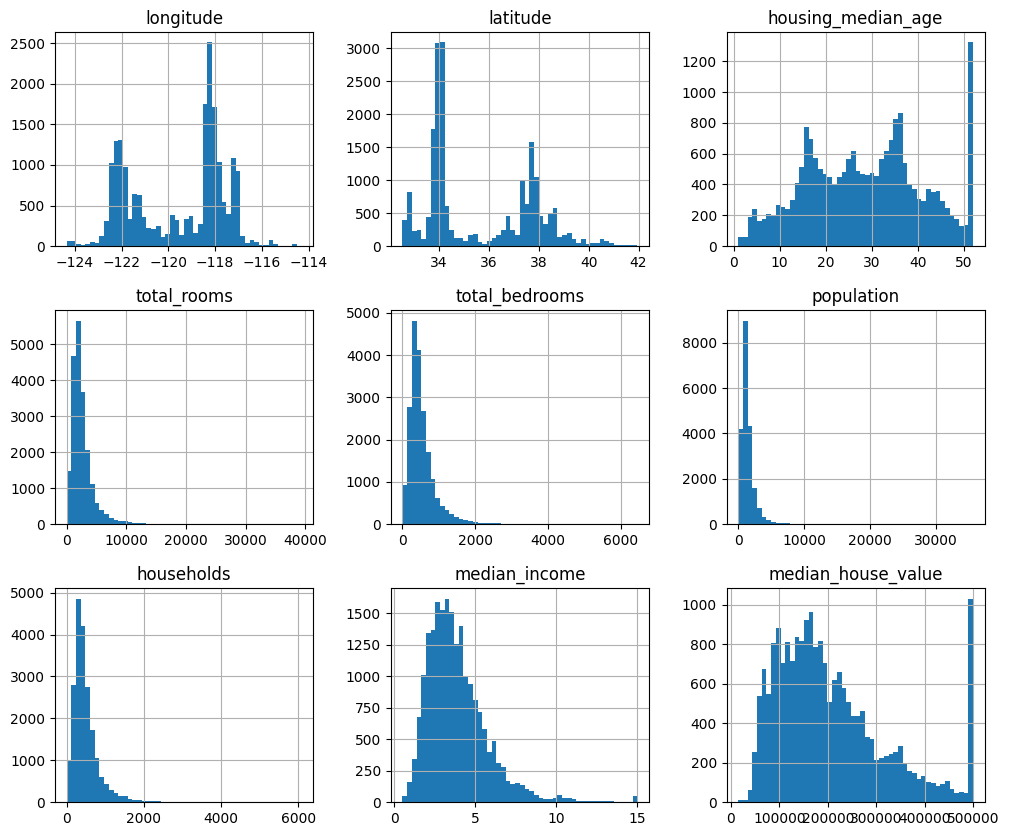

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


# 1. EDA
df = pd.read_csv('housing.csv')
df.info()
df.describe()
df.isnull().sum()
df.hist(bins=50, figsize=(12,10))




<Axes: >

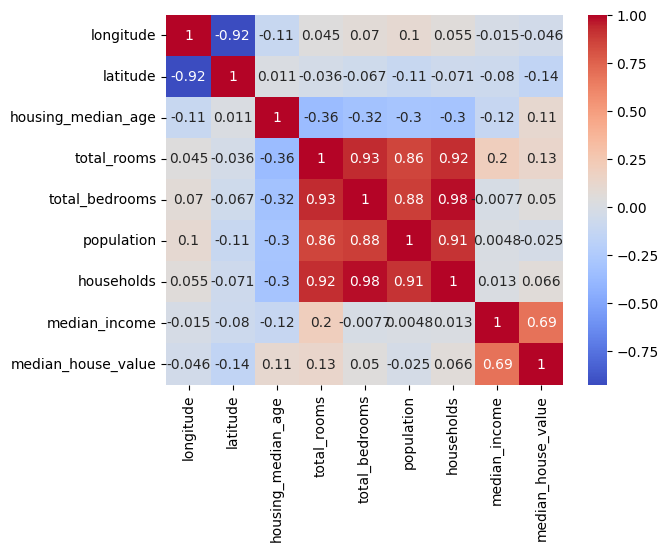

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [16]:
# 2. Preprocessing
# Missing values
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Feature encoding (ocean_proximity is categorical)
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Define X and y
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [17]:
# 3. Build model
model = LinearRegression()
model.fit(X_train_scaled, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
# 4. Interpret coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coef_df.sort_values('Coefficient', ascending=False))



                       Feature   Coefficient
7                median_income  75167.774766
4               total_bedrooms  43068.181842
6                   households  18382.196324
2           housing_median_age  13889.866189
9       ocean_proximity_ISLAND   2118.437572
11  ocean_proximity_NEAR OCEAN   1139.905592
10    ocean_proximity_NEAR BAY  -1621.705018
3                  total_rooms -13094.251162
8       ocean_proximity_INLAND -18506.095225
5                   population -43403.432427
0                    longitude -53826.648016
1                     latitude -54415.696144


R²: 0.6254240620553606
MSE: 4908476721.156616


Text(0, 0.5, 'Residuals')

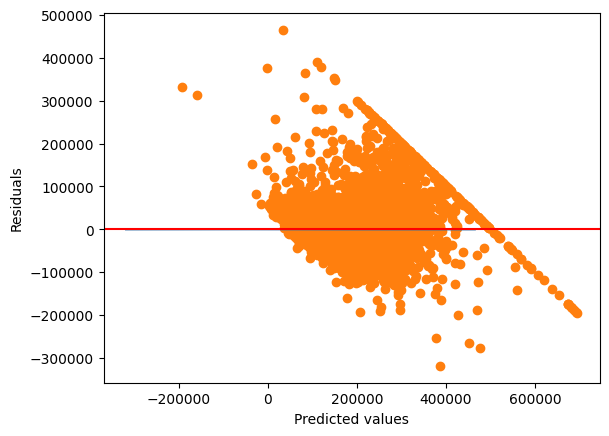

In [19]:
# 5. Evaluate
y_pred = model.predict(X_test_scaled)
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Residual analysis
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")

## Question 2: Classification & Logistic Regression – Employee Attrition or Credit Risk

### Scenario

You are hired by an organization to build a system that predicts a **binary outcome**:

* Whether an **employee will leave** the company, OR
* Whether a **customer will default** on a credit card payment.

### Datasets (Choose ONE)

* **IBM HR Analytics Employee Attrition Dataset**
  [https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

* **Credit Card Default Dataset**
  [https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)

### Tasks

1. Justify why **Logistic Regression** is suitable for this problem.
2. Perform full **data preprocessing**:

   * Missing value handling
   * Encoding categorical variables
   * Feature scaling
3. Train a **Logistic Regression** classifier.
4. Evaluate the model using:

   * Confusion Matrix
   * Precision, Recall, F1-score
   * AUC Score
5. Interpret model coefficients using **odds ratios**.
6. Discuss the impact of **class imbalance** and possible solutions.

In [22]:
ucl_df = pd.read_csv('/home/supriya-devkota/Desktop/DSML/DataScience/Assignment/UCI_Credit_Card.csv', index_col=0)
ucl_df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


1. Why Logistic Regression is suitable

The target (default.payment.next.month) is binary (default vs no default), and logistic regression is designed exactly for binary classification. It outputs probabilities (0–1) via the sigmoid function, which is interpretable as risk of default — useful for credit decisions. It's also fast, interpretable (coefficients map to odds ratios for business explanation), and works well as a baseline before trying complex models

In [27]:
#2) Data Preprocessing

# Missing values
ucl_df.isnull().sum()  # this dataset usually has no missing values
# If any: ucl_df.fillna(ucl_df.median(), inplace=True)

# Categorical encoding
# SEX, EDUCATION, MARRIAGE are already numeric-coded but categorical in nature
ucl_df = pd.get_dummies(ucl_df, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

# Define X, y
X = ucl_df.drop('default.payment.next.month', axis=1)
y = ucl_df['default.payment.next.month']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

In [32]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000

AUC: 0.7100800813278867


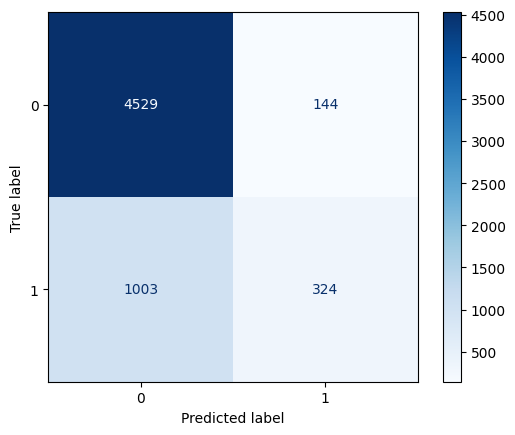

In [35]:
# Evaluation
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')

# Precision, Recall, F1
print(classification_report(y_test, y_pred))

# AUC
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

In [37]:
#Interpret coefficients via odds ratios
odds_ratios = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Odds Ratio', ascending=False)
print(odds_ratios)

        Feature  Coefficient  Odds Ratio
2         PAY_0     0.660328    1.935426
27   MARRIAGE_1     0.559916    1.750526
28   MARRIAGE_2     0.470747    1.601190
21  EDUCATION_1     0.215384    1.240338
22  EDUCATION_2     0.176018    1.192459
29   MARRIAGE_3     0.117091    1.124222
23  EDUCATION_3     0.107497    1.113487
9     BILL_AMT2     0.106244    1.112094
4         PAY_3     0.093958    1.098514
3         PAY_2     0.093340    1.097835
11    BILL_AMT4     0.067895    1.070253
5         PAY_4     0.060350    1.062208
1           AGE     0.053469    1.054925
12    BILL_AMT5     0.036020    1.036676
10    BILL_AMT3     0.028891    1.029313
7         PAY_6     0.015249    1.015365
26  EDUCATION_6     0.008966    1.009007
6         PAY_5    -0.000240    0.999760
18     PAY_AMT5    -0.018581    0.981591
13    BILL_AMT6    -0.023115    0.977150
19     PAY_AMT6    -0.030716    0.969751
16     PAY_AMT3    -0.034986    0.965619
17     PAY_AMT4    -0.035813    0.964821
24  EDUCATION_4 

In [38]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## Question 3: Hyperparameter Tuning & Model Optimization

### Scenario

After deploying your classification model, stakeholders ask you to **improve performance** without changing the dataset.

You decide to optimize the model using systematic hyperparameter search techniques.

### Dataset

Reuse the dataset from **Question 2**.

### Tasks

1. Explain the difference between **parameters** and **hyperparameters**.
2. Train a **baseline Logistic Regression** model.
3. Apply **GridSearchCV** to tune hyperparameters (`C`, `penalty`, `solver`).
4. Apply **RandomizedSearchCV** and compare results.
5. Compare performance before and after tuning.
6. Discuss trade-offs between **computational cost** and **model performance**.

1. Parameters vs hyperparametersParameters are values the model learns from data during training (e.g. logistic regression's coefficients/weights and intercept). Hyperparameters are settings you choose before training that control how the model learns (e.g. C, penalty, solver) — they aren't learned, they're tuned via search.

In [39]:
#2 Baseline model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train_scaled, y_train)
y_pred_base = baseline.predict(X_test_scaled)
y_prob_base = baseline.predict_proba(X_test_scaled)[:, 1]

print("Baseline AUC:", roc_auc_score(y_test, y_prob_base))
print(classification_report(y_test, y_pred_base))

Baseline AUC: 0.7100800813278867
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [40]:
#3) Grid Search for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'penalty': ['l1'], 'solver': ['liblinear', 'saga'], 'C': [0.01, 0.1, 1, 10, 100]},
    {'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear', 'saga'], 'C': [0.01, 0.1, 1, 10, 100]}
]

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid,
                     scoring='roc_auc', cv=5, n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params (Grid):", grid.best_params_)
print("Best CV AUC (Grid):", grid.best_score_)

y_prob_grid = grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]
print("Test AUC (Grid):", roc_auc_score(y_test, y_prob_grid))

/home/supriya-devkota/Desktop/DSML/DataScience/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/supriya-devkota/Desktop/DSML/DataScience/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/supriya-devkota/Desktop/DSML/DataScience/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_

Best params (Grid): {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC (Grid): 0.7278118303631358
Test AUC (Grid): 0.7101768388073608


In [41]:
#4) Randomized Search for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_dist = {
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'C': uniform(0.001, 100)
}

random_search = RandomizedSearchCV(LogisticRegression(max_iter=1000), param_dist,
                                    n_iter=20, scoring='roc_auc', cv=5,
                                    random_state=42, n_jobs=-1)
random_search.fit(X_train_scaled, y_train)

print("Best params (Random):", random_search.best_params_)
print("Best CV AUC (Random):", random_search.best_score_)

y_prob_rand = random_search.best_estimator_.predict_proba(X_test_scaled)[:, 1]
print("Test AUC (Random):", roc_auc_score(y_test, y_prob_rand))

/home/supriya-devkota/Desktop/DSML/DataScience/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/supriya-devkota/Desktop/DSML/DataScience/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/supriya-devkota/Desktop/DSML/DataScience/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_

Best params (Random): {'C': np.float64(5.809361216819947), 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC (Random): 0.7278114773566517
Test AUC (Random): 0.7101660342221529


In [42]:
#compare before and after tuning
results = pd.DataFrame({
    'Model': ['Baseline', 'GridSearchCV', 'RandomizedSearchCV'],
    'Test AUC': [
        roc_auc_score(y_test, y_prob_base),
        roc_auc_score(y_test, y_prob_grid),
        roc_auc_score(y_test, y_prob_rand)
    ]
})
print(results)

                Model  Test AUC
0            Baseline  0.710080
1        GridSearchCV  0.710177
2  RandomizedSearchCV  0.710166



6. Trade-offs: computational cost vs performance

GridSearchCV exhaustively tries every combination — guaranteed to find the best within the grid, but cost grows multiplicatively with each added hyperparameter/value (combinatorial explosion). With 2 penalties × 3 solvers × 5 C values × 5-fold CV = 150 fits.
RandomizedSearchCV samples a fixed number of combinations from the distributions — much cheaper (e.g. 20 × 5 = 100 fits regardless of grid size), and often finds near-optimal settings, especially when only a few hyperparameters actually matter.